# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Implementation of Fibonacci Retracement Strategy

You have already learned how to plot the fibonacci ratios along with the price data. To recap, you had used the daily data of Apple stock. In this notebook, you will use minute-data of Apple stock price and implement a trading strategy using fibonacci ratios.

The notebook is structured as follows:
1. [Import the Libraries](#import)
2. [Resample Asset Data](#asset)
3. [Pre-requisite for Fibonacci Ratios](#pre)
4. [Calculate Fibonacci Ratios](#cal_fibo)
5. [Merging the Dataset](#merge)
5. [Backtest Fibonacci Retracement Strategy](#backtest)
6. [Summary](#summary)

<a id='import'></a>
## Import Libraries

- You will use the `pandas` library to store as well as perform various calculations on the price data. 
- In order to create conditions for generating buy or sell signals, you will use the `numpy` library. 
- In order to work with minute data, you will use `timedelta` function of the `datetime` library. 
- Further, you will use the `matplotlib` library to plot the fibonacci ratios as well as the price data.

As you have seen before, you will use the user-defined functions `backtester`,`trade_level_analytics`, and `get_performance_metrics` from the `price_action_util_quantra.py` module for backtesting and evaluating the strategy. This module is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

Python is a user-friendly language and displays messages to improve the code. You can suppress these warnings by usig the `warnings` library and filtering them. Don't worry, it will not ignore any errors though.

In [1]:
# For data manipulation
import numpy as np
import pandas as pd
from datetime import timedelta

# For data visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# For backtesting and evaluating strategy
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import backtester, trade_level_analytics, get_performance_metrics

# For warnings suppression
import warnings
warnings.filterwarnings("ignore")

You will import the file `aapl_minute_data_2014_2021.csv` as it contains the minute-wise price data of the Apple stock for the period 2014 to 2021. This data will be stored in a dataframe named `data`.

You will use the `read_csv` method of `pandas` to import this file.

Note: This file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

Further, the time stamp is in string format. In order to perform data manipulation, we will convert this to a `date-time` format which will help us split the data according to time.

In [2]:
# Read CSV file using read_csv method of pandas
data = pd.read_csv(
    '../data_modules/aapl_minute_data_2014_2021.csv', index_col=0)

# Convert the index to datetime
data.index = pd.to_datetime(data.index)

data.columns = ['Close','High','Low','Open','Volume']
# Print the first 5 rows of the dataframe
data.head()

,Close,High,Low,Open,Volume
2014-12-05 13:00:00+00:00,28.9525,28.9650,28.9375,28.9625,20359.75
2014-12-05 13:01:00+00:00,28.9450,28.9550,28.9450,28.9525,9703.50
2014-12-05 13:02:00+00:00,28.9450,28.9450,28.9275,28.9425,13642.50
2014-12-05 13:03:00+00:00,28.9225,28.9525,28.9200,28.9450,23631.00
2014-12-05 13:04:00+00:00,28.9225,28.9250,28.9125,28.9200,10529.50


<a id='asset'></a>
## Resample Asset Data

To implement the fibonacci retracement strategy, you need data in two timeframes. 

### Why do you need two timeframes to develop the fibonacci retracement strategy?

You would need a monthly data timeframe to calculate the fibonacci levels and identify the ideal level to take trades. Once you have identified the price levels, you will take 30-minute timeframes to identify the right time to buy or sell an asset. 
Note that the choice of timeframe parameters is arbitrary. Instead of monthly data, you can use daily timeframes as well, as it was shown in the previous notebook. And instead of 30-minute timeframes, you can take hourly data, or even 4 hours. 

For now, you will store the two timeframes data in different timeframes which will be merged later. In the dataframe consisting of monthly data, it shows the timestamp of 12 am by default. Since we are going to merge the dataframes later, we will set the timestamp to 16:00 to indicate that the price was captured at the end of the last trading day of the month. 

In [3]:
# Aggregate function to be used later for resampling
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last',
              'Volume': 'sum'
              }

# Resample minute data to 30-min frequency
data_30min = data.resample('30min', label='right',
                           closed='right').agg(ohlcv_dict).dropna()

# Resample to minute data to monthly frequency
data_monthly = data.resample(
    '1MS', label='right', closed='right').agg(ohlcv_dict).dropna()

# Adding timestamp of 16:00:000 to indicate price captured
# at end of last trading day of the month
data_monthly.index += timedelta(hours=16, minutes=0)

# Print first 5 rows of monthly data
data_monthly.head()

,Open,High,Low,Close,Volume
2015-01-01 16:00:00+00:00,28.9625,28.9675,26.5650,27.5950,1.784764e+08
2015-02-01 16:00:00+00:00,27.8475,30.0000,26.1575,29.2900,2.805696e+08
2015-03-01 16:00:00+00:00,29.5100,33.4000,29.0200,32.1175,2.605482e+08
2015-04-01 16:00:00+00:00,32.3100,32.5700,30.4075,31.1125,2.527130e+08
2015-05-01 16:00:00+00:00,31.1950,33.6350,30.7750,31.3050,2.208487e+08


<a id='pre'></a>
## Pre-requisite for Fibonacci Ratios

A necessary pre-requisite for calculating the fibonacci ratios is the maximum and minimum price of an asset. In the notebook for calculating fibonacci ratios, you had calculated the ratios for the entire time period. 

In this notebook, you will try to calculate the fibonacci ratios for one year at a time. Thus, you will have different minimum and maximum prices throughout our dataset time period. 

Further, we want to calculate fibonacci ratios for the time period when the asset is on an uptrend. To check this condition, you will also check if the date at which the asset reached the maximum price in a year, is after the date at which the asset reached the minimum price of the year.

Finally, to create a more robust strategy, you will have to confirm if the maximum price is more than 25% of the minimum price. This will help us deploy the strategy only on those time periods when there was a strong trend.

To summarise, the two conditions are as follows

1. The price series is on an uptrend
2. The maximum price is more than 25% of the minimum price

The monthly data timeframes will be used to identify the maximum and minimum price of one year at a time. 

In [4]:
# Calculate the minimum price of the stock during the period of one year
# Since it is monthly data, we use the rolling method and pass
# the parameter as 12
data_monthly['price_min'] = data_monthly.Close.rolling(12).min()

# Calculate the maximum price of the stock during the period of one year
data_monthly['price_max'] = data_monthly.Close.rolling(12).max()

# Create columns to store the date on which the maximum
# and minimum price was recorded for the year
data_monthly['min_dates'] = np.nan
data_monthly['max_dates'] = np.nan

# Create a for loop to store the dates on which the minimum
# and maximum price was recorded

for i in range(0, len(data_monthly)):
    
    # Take range of 1 year
    lookback = data_monthly[i-11:i+1]
    min_value = data_monthly.iloc[i]['price_min']
    max_value = data_monthly.iloc[i]['price_max']
    
    try:
        data_monthly['min_dates'].iloc[i] = str(
            lookback.loc[lookback.Close == min_value].index[0].date())
    
        data_monthly['max_dates'].iloc[i] = str(
            lookback.loc[lookback.Close == max_value].index[0].date())
    except:
        pass

# Check whether the max_date comes after the min_date, i.e. the date on which
# the maximum price was recorded, came after the date on which the minimum price was recorded 
data_monthly['date_signal'] = data_monthly['max_dates'] > data_monthly['min_dates']

# Check whether the maximum price is more than 25% of the minimum price
data_monthly['max_min'] = ((data_monthly['price_max'] - data_monthly['price_min'])/ data_monthly['price_min']) > 0.20

# Print the last 5 rows of monthly data
data_monthly.tail()

,Open,High,Low,Close,Volume,price_min,price_max,min_dates,max_dates,date_signal,max_min
2020-11-01 16:00:00+00:00,117.70,128.19,105.150,108.90,2.573202e+09,63.575,128.85,2020-04-01,2020-09-01,True,True
2020-12-01 16:00:00+00:00,109.14,121.99,107.320,119.04,1.857756e+09,63.575,128.85,2020-04-01,2020-09-01,True,True
2021-01-01 16:00:00+00:00,120.98,138.79,114.090,132.58,1.934789e+09,63.575,132.58,2020-04-01,2021-01-01,True,True
2021-02-01 16:00:00+00:00,128.88,146.25,126.380,131.83,1.806944e+09,63.575,132.58,2020-04-01,2021-01-01,True,True
2021-03-01 16:00:00+00:00,133.68,139.53,130.919,135.12,5.644674e+08,63.575,135.12,2020-04-01,2021-03-01,True,True


<a id='cal_fibo'></a>
## Calculate Fibonacci Ratios

You will now calculate the fibonacci ratios for the datasets. You have already seen the calculations in the previous notebook.

In [5]:
# Calculate the trend_rangeerence in price between the minimum
# and maximum price
trend_range = data_monthly['price_max'] - data_monthly['price_min']

# Calculate the fibonacci ratio value corresponding to 23.6%
data_monthly['fib_23'] = data_monthly['price_max'] - 0.236 * trend_range

# Calculate the fibonacci ratio value corresponding to 38.2%
data_monthly['fib_38'] = data_monthly['price_max'] - 0.382 * trend_range

# Calculate the fibonacci ratio value corresponding to 50%
data_monthly['fib_50'] = data_monthly['price_max'] - 0.500 * trend_range

# Calculate the fibonacci ratio value corresponding to 61.8%
data_monthly['fib_61'] = data_monthly['price_max'] - 0.618 * trend_range

# Calculate the fibonacci ratio value corresponding to 78.6%
data_monthly['fib_78'] = data_monthly['price_max'] - 0.786 * trend_range

# Drop any rows which have NaN values
data_monthly.dropna(axis=0, how='any', inplace=True)

# Print the last five rows of the monthly frequency dataset
data_monthly.tail()

,Open,High,Low,Close,Volume,price_min,price_max,min_dates,max_dates,date_signal,max_min,fib_23,fib_38,fib_50,fib_61,fib_78
2020-11-01 16:00:00+00:00,117.70,128.19,105.150,108.90,2.573202e+09,63.575,128.85,2020-04-01,2020-09-01,True,True,113.44510,103.91495,96.2125,88.51005,77.54385
2020-12-01 16:00:00+00:00,109.14,121.99,107.320,119.04,1.857756e+09,63.575,128.85,2020-04-01,2020-09-01,True,True,113.44510,103.91495,96.2125,88.51005,77.54385
2021-01-01 16:00:00+00:00,120.98,138.79,114.090,132.58,1.934789e+09,63.575,132.58,2020-04-01,2021-01-01,True,True,116.29482,106.22009,98.0775,89.93491,78.34207
2021-02-01 16:00:00+00:00,128.88,146.25,126.380,131.83,1.806944e+09,63.575,132.58,2020-04-01,2021-01-01,True,True,116.29482,106.22009,98.0775,89.93491,78.34207
2021-03-01 16:00:00+00:00,133.68,139.53,130.919,135.12,5.644674e+08,63.575,135.12,2020-04-01,2021-03-01,True,True,118.23538,107.78981,99.3475,90.90519,78.88563


<a id='merge'></a>
## Merging the Dataset

In order to create the trading strategy, we need both the 30-minute and monthly datasets.

We will first drop the `Open`,`Low`, and `High` price columns since we will not use them in our strategy. Further, we will rename the `Close` column of monthly timeframe to `Monthly Close` in order to differentiate between the monthly and 30-minute close prices of the asset. 

Finally, you will use the `merge` method of `Pandas` library to merge the two dataframes.

In [6]:
# Retain only necessary columns
data_monthly = data_monthly[['Close', 'price_min', 'price_max', 'date_signal', 'max_min', 'fib_23',
                             'fib_38', 'fib_50', 'fib_61', 'fib_78']]

# Renaming the column Close since both datasets have same name
data_monthly.rename(columns={'Close':'monthly_close'}, inplace=True)

# Merging the 30-minute and monthly datasets
fibo = pd.merge(data_30min, data_monthly, left_index=True,
                right_index=True, how='outer')

# Filling any rows consisting of NaN values with ffill parameter
fibo = fibo.fillna(method='ffill')

# Dropping rows with nan values (Ideally days where monthly close = 0, first few days)
fibo.dropna(axis=0, how='any', inplace=True)

# Using index of 30-minute dataset
fibo = fibo[fibo.index.isin(data_30min.index)]

# Print the first 5 rows of the dataset
fibo.head()

,Open,High,Low,Close,Volume,monthly_close,price_min,price_max,date_signal,max_min,fib_23,fib_38,fib_50,fib_61,fib_78
2015-12-01 16:00:00+00:00,29.2850,29.3450,29.2150,29.3225,1030506.50,29.5925,27.5725,32.58,False,False,31.39823,30.667135,30.07625,29.485365,28.644105
2015-12-02 09:30:00+00:00,29.2525,29.3325,29.2500,29.3325,85142.50,29.5925,27.5725,32.58,False,False,31.39823,30.667135,30.07625,29.485365,28.644105
2015-12-02 10:00:00+00:00,29.3325,29.4500,29.2525,29.4125,873414.00,29.5925,27.5725,32.58,False,False,31.39823,30.667135,30.07625,29.485365,28.644105
2015-12-02 10:30:00+00:00,29.4125,29.4450,29.3600,29.3825,623670.75,29.5925,27.5725,32.58,False,False,31.39823,30.667135,30.07625,29.485365,28.644105
2015-12-02 11:00:00+00:00,29.3800,29.5275,29.3350,29.4575,716949.25,29.5925,27.5725,32.58,False,False,31.39823,30.667135,30.07625,29.485365,28.644105


<a id='backtest'></a>
## Backtest Fibonacci Retracement Strategy

You have created a dataframe `fibo` which contains both the 30-min and monthly timeframe data. First, you will filter the dataframe and select only the time period when the following conditions are met:

1. The price series is on an uptrend
2. The maximum price is more than 25% of minimum price

You have already created the signals for these two conditions and stored them in the `date_signal` and `max_min` column of the `fibo` dataframe.

In [7]:
# Store only the time period where both conditions are met
fibo = fibo.loc[fibo['date_signal'] & fibo['max_min']]

# Print the first 5 rows of the dataframe
fibo.head()

,Open,High,Low,Close,Volume,monthly_close,price_min,price_max,date_signal,max_min,fib_23,fib_38,fib_50,fib_61,fib_78
2016-12-01 16:00:00+00:00,27.3625,27.3900,27.2575,27.3675,1330479.75,27.63,23.4375,28.39,True,True,27.22121,26.498145,25.91375,25.329355,24.497335
2016-12-02 09:30:00+00:00,27.3225,27.4300,27.2925,27.4225,266682.25,27.63,23.4375,28.39,True,True,27.22121,26.498145,25.91375,25.329355,24.497335
2016-12-02 10:00:00+00:00,27.4225,27.5225,27.2500,27.3800,884389.75,27.63,23.4375,28.39,True,True,27.22121,26.498145,25.91375,25.329355,24.497335
2016-12-02 10:30:00+00:00,27.3800,27.4225,27.2125,27.3075,641836.75,27.63,23.4375,28.39,True,True,27.22121,26.498145,25.91375,25.329355,24.497335
2016-12-02 11:00:00+00:00,27.3075,27.3775,27.2750,27.3400,477739.00,27.63,23.4375,28.39,True,True,27.22121,26.498145,25.91375,25.329355,24.497335


The essence of the fibonacci retracement strategy is the assumption that the price will go above the fibonacci level of 50% and then decline. The price is in between the fibonacci ratios of 38.6 and 50%, before retracing and going up again.

In the fibonacci retracement strategy, we want to buy only when the price falls and goes in the level between 38.6 and 50%. This is why we use the simple moving average and buy only when the simple moving average is above the closing price, indicating that the price is falling.

As per the strategy discussed in the video, you will first create the necessary conditions to generate the buy and sell signals. Let us first look at the conditions to generate the buy signals. These are:

1. Close price should be between the fibonacci ratio between 38.6% and 50%
2. The 21-day, or monthly SMA value should be more than the fibonacci ratio corresponding to 50%

In [8]:
# Check if the close prices is between the 38.6% and 50% levels
cond_1 = fibo['Close'] < fibo['fib_38']
cond_2 = fibo['Close'] > fibo['fib_50']

# Store the signal 1 in the buy_zone column only when above 2 conditions
# are met, otherwise store 0
fibo['buy_zone'] = np.where(cond_1 & cond_2, 1, 0)

# Compute 21-Day SMA (The number of 30 Min Bars in a day are 13 & 21 days in a month)
fibo['21_Day_SMA'] = fibo['Close'].rolling(13*21).mean()

# Set the condition that the 21-day SMA should be more than
# fibonacci ratio corresponding to 50%
sma_condition = fibo['21_Day_SMA'] > fibo['fib_50']

# Store the signal 1 in the SMA_signal column
# when the SMA condition is met, otherwise 0
fibo['SMA_signal'] = np.where(sma_condition, 1, 0)

You have created the conditions and stored the results in the `buy_zone` and the `SMA_signal` columns of the `fibo` dataframe. Now, you will generate a buy signal only when these two conditions are true.

### What is our exit, or sell signal condition?

When either of the above conditions is not met, we will exit, or sell our stock.

In [9]:
# Create a signal column which is set to 1 only
# when the two conditions are met, otherwise 0
fibo['signal'] = fibo['buy_zone'] * fibo['SMA_signal']

Apart from the buy and sell signal, we will also set the take-profit and stop-loss levels.
The stop-loss will correspond to the fibonacci ratio corresponding to the 61.8% fibonacci level.
Further, the take-profit level should correspond to the fibonacci ratio corresponding to the fibonacci level of 23%.
You can, of course, try to set the stop-loss and take-profit levels at different levels and understand how it impacts the price performance.

Note that the take-profit level is stored in the column `target` of the dataframe `fibo`.

In [10]:
# Determine the stop-loss level
fibo['stoploss'] = fibo['fib_61']

# Determine the take-profit level
fibo['target'] = fibo['fib_23']

# Print the first 5 rows of the dataset
fibo.head()

,Open,High,Low,Close,Volume,monthly_close,price_min,price_max,date_signal,max_min,...,fib_38,fib_50,fib_61,fib_78,buy_zone,21_Day_SMA,SMA_signal,signal,stoploss,target
2016-12-01 16:00:00+00:00,27.3625,27.3900,27.2575,27.3675,1330479.75,27.63,23.4375,28.39,True,True,...,26.498145,25.91375,25.329355,24.497335,0,NaN,0,0,25.329355,27.22121
2016-12-02 09:30:00+00:00,27.3225,27.4300,27.2925,27.4225,266682.25,27.63,23.4375,28.39,True,True,...,26.498145,25.91375,25.329355,24.497335,0,NaN,0,0,25.329355,27.22121
2016-12-02 10:00:00+00:00,27.4225,27.5225,27.2500,27.3800,884389.75,27.63,23.4375,28.39,True,True,...,26.498145,25.91375,25.329355,24.497335,0,NaN,0,0,25.329355,27.22121
2016-12-02 10:30:00+00:00,27.3800,27.4225,27.2125,27.3075,641836.75,27.63,23.4375,28.39,True,True,...,26.498145,25.91375,25.329355,24.497335,0,NaN,0,0,25.329355,27.22121
2016-12-02 11:00:00+00:00,27.3075,27.3775,27.2750,27.3400,477739.00,27.63,23.4375,28.39,True,True,...,26.498145,25.91375,25.329355,24.497335,0,NaN,0,0,25.329355,27.22121


Once we have generated the buy and sell signals, we will now backtest the trading strategy using the user-defined function `backtester` in the `price_action_util_quantra.py` module which is stored in the `data_modules` folder. This file is also available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

Let's call the function to backtest our strategy

In [11]:
# Call the function to backtest fibonacci retracement strategy
tradesheet = backtester(fibo)

Trade No: 1 | Entry Date: 2018-02-05 16:00:00+00:00 | Entry Price: 39.12 | Position: 1
Exit Type: TP | Exit Date: 2018-02-13 13:30:00+00:00 | Exit Price: 40.94 | PnL: 1.82 | Cum PnL: 1.82
------------------------------
Trade No: 2 | Entry Date: 2018-04-02 14:00:00+00:00 | Entry Price: 41.22 | Position: 1
Exit Type: TP | Exit Date: 2018-04-04 14:30:00+00:00 | Exit Price: 42.65 | PnL: 1.43 | Cum PnL: 3.25
------------------------------
Trade No: 3 | Entry Date: 2018-04-23 13:30:00+00:00 | Entry Price: 41.2 | Position: 1
Exit Type: TP | Exit Date: 2018-05-02 09:30:00+00:00 | Exit Price: 43.72 | PnL: 2.52 | Cum PnL: 5.77
------------------------------
Trade No: 4 | Entry Date: 2018-11-05 09:30:00+00:00 | Entry Price: 50.81 | Position: 1
Exit Type: SL | Exit Date: 2018-11-14 11:30:00+00:00 | Exit Price: 47.2 | PnL: -3.61 | Cum PnL: 2.16
------------------------------
Trade No: 5 | Entry Date: 2020-03-12 09:30:00+00:00 | Entry Price: 64.18 | Position: 1
Exit Type: TP | Exit Date: 2020-03-13 

You can see that the strategy took a total of 7 trades. Further, it resulted in a cumulative PnL of 12.15. 

Once you have backtested the strategy and analysed the trades taken as well as the profit or loss associated with the trade, you can use the `trade_level_analytics` function available in the `price_action_util_quantra.py` module to retrieve trade-level measures such as total trades, number of winners and losers as well as their percentages.  

In [12]:
tradesheet.index = range(0, len(tradesheet))
fibo.signal = 0

# Iterate over each row in the 'trades' DataFrame
for index, trade in tradesheet.iterrows():
    # Extract the entry date of the trade
    entry_time = tradesheet['entry_date'][index]
    
    # Extract the exit date of the trade
    exit_time = tradesheet['exit_date'][index]
    
    # Extract the position of the trade (e.g., -1 for short)
    position = tradesheet['position'][index]
    
    # Update the 'signal' column in the 'data' DataFrame for the date range
    # between the entry date and the exit date with the corresponding position
    fibo.loc[entry_time:exit_time, 'signal'] = position

In [13]:
# Call the function to analyse the executed trades
trade_level_analytics(tradesheet)

,Strategy
Total PnL,12.15
total_trades,7
Number of Winners,5
Number of Losers,2
Win (%),71.428571
Loss (%),28.571429
per_trade_PnL_winners,4.06
per_trade_PnL_losers,4.075
Average holding time,8 days 03:25:42.857142857
Profit Factor,2.490798


No strategy is perfect and you can see that you took a loss in 2 of the executed trades. However, you can also see that the strategy's win percentage is higher than the loss percentage, resulting in a positive profit factor. 

Along with the trade level analytics, you would like to know about the strategy performance, for which you can use the user-defined function `get_performance_metrics` present in the `price_action_util_quantra.py` module. 

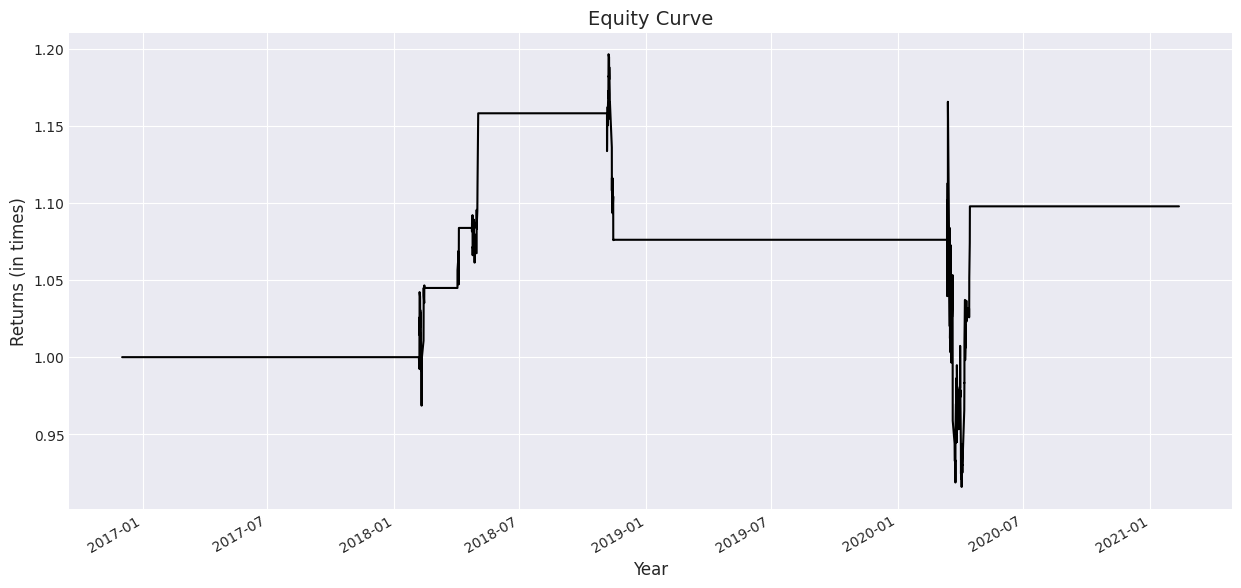

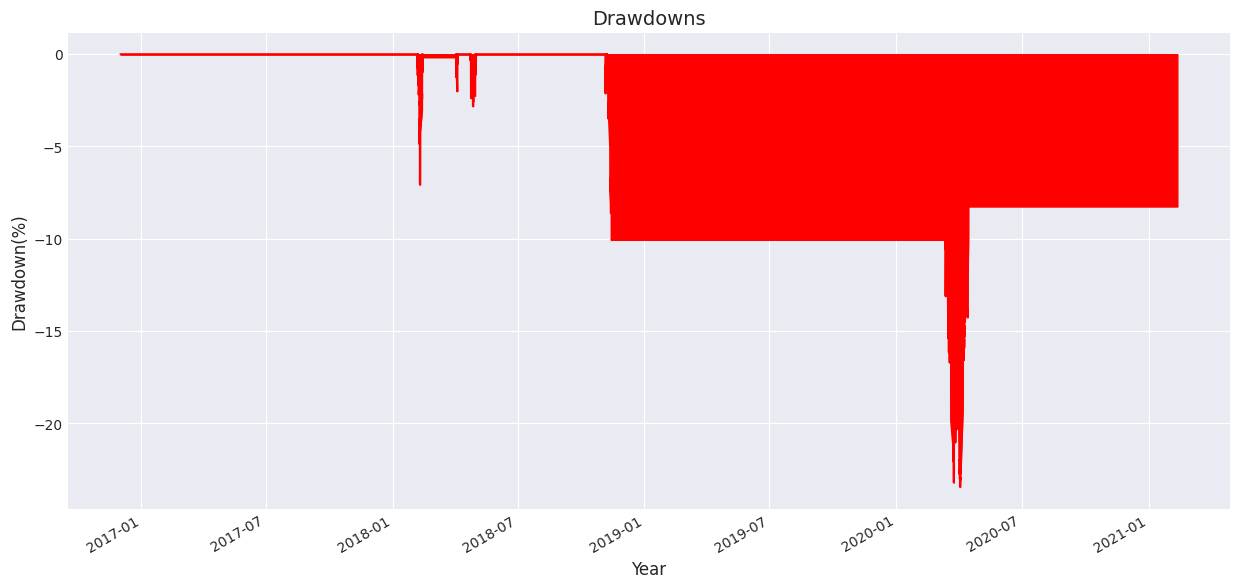

                 Strategy
CAGR                2.79%
Sharpe Ratio         0.13
Maximum Drawdown  -23.45%


In [14]:
# Call the function to analyse the strategy performance
get_performance_metrics(fibo)

You can see that the cumulative returns is 1.1 in a period of 4 years. Further, the sharpe ratio is 0.13 but the maximum drawdown of -23% is not too high. You can tweak the parameters and analyse if it helps improve the strategy or not. Further, you can change the timeframe needed as well to calculate the fibonacci ratios. Consider this your base strategy and any changes made in the strategy should help improve its performance.

<a id='summary'></a>
## Summary

You have not only calculated, but backtested the fibonacci retracement strategy on real-world minute data of a stock. You saw that the strategy has more winning trades than losing trades. The cumulative returns can be improved by choosing different parameters for take profit and stoploss, which might impact your drawdowns. You can try this strategy on other stocks as well. Good luck!
<br><br>